<a href="https://colab.research.google.com/github/analauraboliveira/Estudos-Aprendizado-de-Maquina/blob/main/Pr%C3%A1tica_2_Ana_Laura_e_Ana_Raquel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prática 2 — Avaliar e explorar

Integrantes: Ana Laura Barboza Oliveira dos Santos e Ana Raquel Rodrigues da Silva.

# Configuração

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [ ]:
dados = df[
    [
        "Survived",
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare"
    ]
].copy()

dados["Sex"] = (
    dados["Sex"] == "female"
).astype(int)

dados["Age"] = (
    dados["Age"].fillna(
        dados["Age"].median()
    )
)

X = dados.drop(
    columns="Survived"
)

y = dados["Survived"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_tr,
    y_tr
)

print(
    "Teste :",
    knn.score(X_te, y_te)
)

print(
    "Treino:",
    knn.score(X_tr, y_tr)
)

Teste : 0.6791044776119403
Treino: 0.8089887640449438


**Teste:** aproximadamente 0.679.

**Treino:** aproximadamente 0.809.

# Bloco 1 — O resultado depende da divisão?

**1.1 Fazendo vários sorteios**

In [ ]:
acuracias = []

for semente in range(30):
    Xa, Xb, ya, yb = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=semente,
        stratify=y
    )

    modelo = KNeighborsClassifier(
        n_neighbors=5
    )

    modelo.fit(
        Xa,
        ya
    )

    acuracias.append(
        modelo.score(
            Xb,
            yb
        )
    )

acuracias = np.array(
    acuracias
)

print(
    "Mínimo:",
    acuracias.min().round(3)
)

print(
    "Média:",
    acuracias.mean().round(3)
)

print(
    "Máximo:",
    acuracias.max().round(3)
)

Mínimo: 0.66
Média: 0.706
Máximo: 0.75


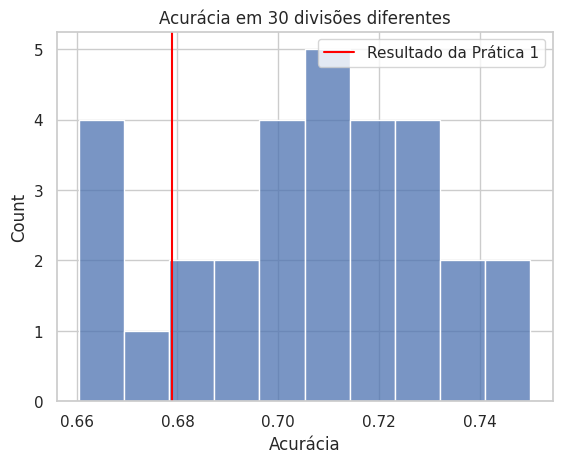

In [ ]:
sns.histplot(
acuracias,
bins=10
)
plt.axvline(
0.679,
color="red",
label="Resultado da Prática 1"
)
plt.xlabel(
"Acurácia"
)
plt.title(
"Acurácia em 30 divisões diferentes"
)
plt.legend()
plt.show()

**Tarefa 1**

**1. Qual foi a menor acurácia?**

Resposta: 0.66.


**2. Qual foi a maior?**

Resposta: 0.75.


**3. Qual foi a média?**

Resposta: 0.706.

**4. O resultado 0,679 da Prática 1 está próximo da média?**

Resposta: Sim, está consideravelmente próximo da média.

**1.2 Validação cruzada**

In [ ]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados = cross_val_score(
    KNeighborsClassifier(
        n_neighbors=5
    ),
    X,
    y,
    cv=cv
)

print(
    resultados.round(3)
)

print(
    "Média:",
    resultados.mean().round(3)
)

print(
    "Desvio:",
    resultados.std().round(3)
)

[0.749 0.73  0.685 0.708 0.674]
Média: 0.709
Desvio: 0.028


**Tarefa 2**

**Cinco resultados:** 0.749, 0.73, 0.685, 0.708 e 0.674.

**1. Qual foi a maior acurácia?**
Resposta: 0.749.

**2. Qual foi a menor?**
Resposta: 0.674.

**3. Qual foi a média?**
Resposta: 0,7092.

**Comparação:**
A média dos resultados fornece uma avaliação mais confiável do desempenho do modelo, pois a variação entre os cinco resultados é menor e mais organizada que ao observar apenas uma divisão isolada. Além disso, observa-se que os valores encontrados são bem próximos.

**1.3 Por que estratificar?**

In [ ]:
from sklearn.model_selection import KFold

def proporcao_classes(gerador):
    proporcoes = []

    for _, teste in gerador.split(X, y):
        proporcoes.append(
            y.iloc[teste].mean()
        )

    return np.round(
        proporcoes,
        3
    )

print(
    "Conjunto completo:",
    round(y.mean(), 3)
)

print(
    "KFold:",
    proporcao_classes(
        KFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )
    )
)

print(
    "Estratificado:",
    proporcao_classes(
        StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )
    )
)

Conjunto completo: 0.384
KFold: [0.413 0.376 0.393 0.371 0.365]
Estratificado: [0.385 0.382 0.382 0.382 0.388]


**Tarefa 3**

**Compare as proporções apresentadas.
Qual estratégia mantém as proporções das classes mais próximas do conjunto original?**

Resposta: A estratégia estratificada mantém as proporções das classes mais próximas da proporção do conjunto original, pois  preserva a distribuição das classes em cada divisão.

**1.4 Escolhendo o valor de k**

In [ ]:
for k in [
    1,
    3,
    5,
    7,
    10,
    15,
    20
]:

    resultados = cross_val_score(
        KNeighborsClassifier(
            n_neighbors=k
        ),
        X,
        y,
        cv=cv
    )

    print(
        "k =",
        k,
        "->",
        resultados.mean().round(3),
        "+/-",
        resultados.std().round(3)
    )

k = 1 -> 0.703 +/- 0.043
k = 3 -> 0.725 +/- 0.036
k = 5 -> 0.709 +/- 0.028
k = 7 -> 0.714 +/- 0.031
k = 10 -> 0.713 +/- 0.023
k = 15 -> 0.718 +/- 0.024
k = 20 -> 0.714 +/- 0.024


**Tarefa 4**

**Qual valor de k apresentou a maior média?**

Resposta: k = 3 (0.725).

**Qual apresentou a menor?**

Resposta: k = 1 (0.703).


###Checkpoint 1

**Histograma das 30 acurácias**

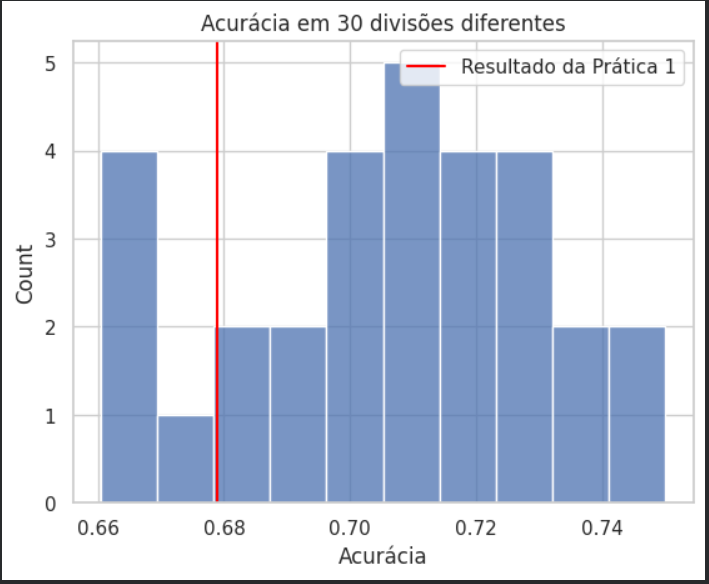


**Resultados da validação cruzada**

0.749, 0.73, 0.685, 0.708 e 0.674.


**Resultados para os diferentes valores de k**

- k = 1 -> 0.703 +/- 0.043
- k = 3 -> 0.725 +/- 0.036
- k = 5 -> 0.709 +/- 0.028
- k = 7 -> 0.714 +/- 0.031
- k = 10 -> 0.713 +/- 0.023
- k = 15 -> 0.718 +/- 0.024
- k = 20 -> 0.714 +/- 0.024

# Bloco 2 — Métricas além da acurácia

**2.1 O baseline**

In [ ]:
y.value_counts()

,count
Survived,
0,549
1,342


In [ ]:
y.value_counts(
    normalize=True
)

,proportion
Survived,
0,0.616162
1,0.383838


**Tarefa 5**

**Imagine um modelo que sempre respondesse: “não sobreviveu”. Qual seria a acurácia desse modelo? Compare esse resultado com o k-NN.**

Resposta: Nesse caso, são 549 não sobreviventes e 342 sobreviventes. Logo: 549 / 891 ≈ 0,616. Ou seja, um modelo que sempre previsse "não sobreviveu" teria aproximadamente 61,6% de acurácia. Já o k-NN, apresenta aproximadamente 67,9% no teste, então consegue um resultado melhor que esse baseline.

**2.2 Matriz de confusão**

[[126  39]
 [ 47  56]]


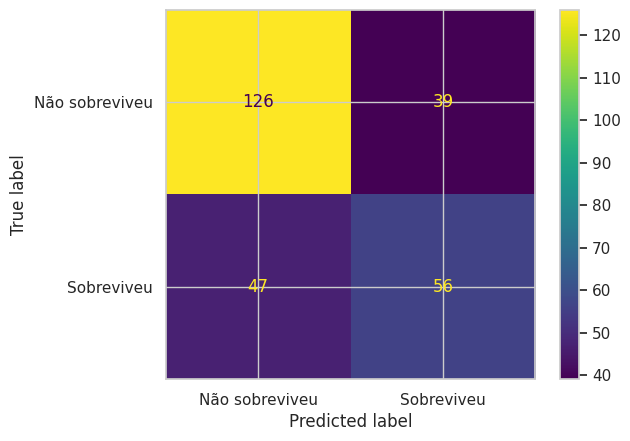

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

previsoes = knn.predict(
    X_te
)

matriz = confusion_matrix(
    y_te,
    previsoes
)

print(matriz)

ConfusionMatrixDisplay(
    matriz,
    display_labels=[
        "Não sobreviveu",
        "Sobreviveu"
    ]
).plot()

plt.show()

**Tarefa 6**

**1. Quantos passageiros que não sobreviveram foram classificados corretamente?**

Resposta: 126 (verdadeiros negativos).

**2. Quantos passageiros que sobreviveram foram classificados corretamente?**

Resposta: 56 (verdadeiros positivos).

**3. Quantos sobreviventes foram classificados como não sobreviventes?**

Resposta: 47 (falsos negativos).

**2.3 Precision, recall e F1**

In [ ]:
from sklearn.metrics import (
    classification_report
)

print(
    classification_report(
        y_te,
        previsoes,
        digits=3,
        target_names=[
            "Não sobreviveu",
            "Sobreviveu"
        ]
    )
)

                precision    recall  f1-score   support

Não sobreviveu      0.728     0.764     0.746       165
    Sobreviveu      0.589     0.544     0.566       103

      accuracy                          0.679       268
     macro avg      0.659     0.654     0.656       268
  weighted avg      0.675     0.679     0.676       268



**Tarefa 7**

Para a classe "sobreviveu":

Precision: 0.589.

Recall:  0.544.

F1-score: 0.566.

A menor das três métricas foi: recall (0.544).

### Checkpoint 2

**Matriz de confusão:**

[[126  39]

 [ 47  56]]

 Imagem:

 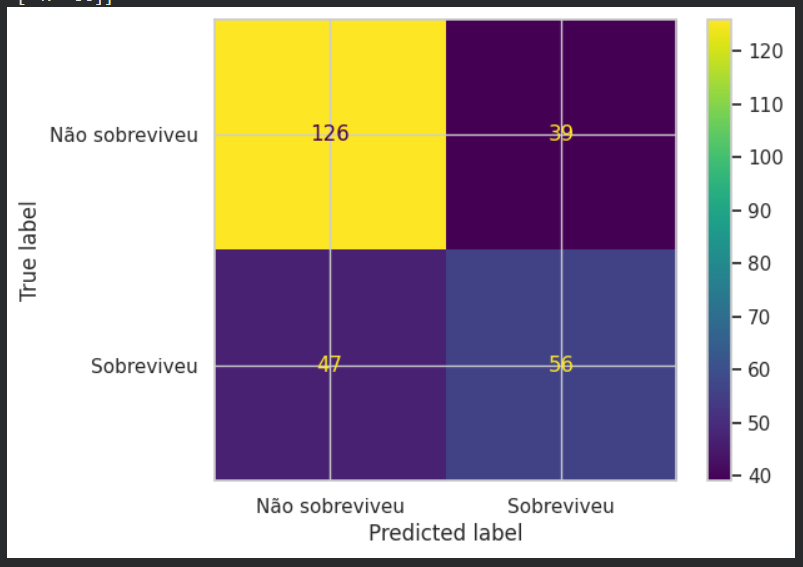


**Classification report:**

Precision (sobreviveu): 0.589.  

Recall (sobreviveu): 0.544.

F1-score (sobreviveu): 0.566.


**Comparação:**
A acurácia mostra a proporção geral de previsões corretas. Já precision, recall e F1 permitem analisar com mais detalhes o desempenho do modelo para cada classe. A acurácia geral foi 0.679, maior que o F1 da classe “sobreviveu”.  Assim, analisar apenas a acurácia não é suficiente para compreender todos os tipos de erro cometidos pelo modelo. Além disso, o modelo acerta mais os casos de “não sobreviveu” e tem dificuldade em identificar sobreviventes.


#  Bloco 3 — Conhecendo o Give Me Some Credit

In [ ]:
url = "https://raw.githubusercontent.com/JLZml/Credit-Scoring-Data-Sets/master/3.%20Kaggle/Give%20Me%20Some%20Credit/cs-training.csv"

credito = pd.read_csv(url)

credito.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
credito.sample(5)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
131468,131469,1,0.775381,28,0,0.072840,3390.0,2,0,0,0,4.0
46865,46866,0,0.075391,45,0,0.211515,2500.0,15,0,1,0,0.0
219,220,0,0.017508,73,1,0.135589,4166.0,12,0,1,0,0.0
84531,84532,0,0.014724,60,0,0.002043,6850.0,5,0,0,0,1.0
112806,112807,0,0.013473,33,0,0.362909,4000.0,9,0,1,0,0.0


**3.2 Conhecendo as colunas**

In [ ]:
credito.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

**3.3 Tamanho e tipos**

In [ ]:
credito.shape

(150000, 12)

In [ ]:
credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [ ]:
credito.dtypes

,0
Unnamed: 0,int64
SeriousDlqin2yrs,int64
RevolvingUtilizationOfUnsecuredLines,float64
age,int64
NumberOfTime30-59DaysPastDueNotWorse,int64
DebtRatio,float64
MonthlyIncome,float64
NumberOfOpenCreditLinesAndLoans,int64
NumberOfTimes90DaysLate,int64
NumberRealEstateLoansOrLines,int64


**Tarefa 8**

**1. Quantas linhas existem?**

Resposta: 150.000.

**2. Quantas colunas existem?**

Resposta: 11.

**3. Qual é a variável-alvo?**

Resposta: A variável SeriousDlqin2yrs.

**4. Quantas variáveis existem além do alvo?**

Resposta: 10.

# Bloco 4 — Primeira EDA

**4.1 Estatísticas básicas**

In [ ]:
credito.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [ ]:
credito["age"].describe()

,age
count,150000.000000
mean,52.295207
std,14.771866
min,0.000000
25%,41.000000
50%,52.000000
75%,63.000000
max,109.000000


In [ ]:
credito["MonthlyIncome"].describe()

,MonthlyIncome
count,1.202690e+05
mean,6.670221e+03
std,1.438467e+04
min,0.000000e+00
25%,3.400000e+03
50%,5.400000e+03
75%,8.249000e+03
max,3.008750e+06


In [ ]:
credito["DebtRatio"].describe()

,DebtRatio
count,150000.000000
mean,353.005076
std,2037.818523
min,0.000000
25%,0.175074
50%,0.366508
75%,0.868254
max,329664.000000


**Tarefa 9**

Variáveis escolhidas: age e MonthlyIncome.

Para age, os valores principais são aproximadamente: média = 52,30, mediana = 52, mínimo = 0 e máximo = 109.

Para MonthlyIncome: média = 6670,22, mediana = 5400, mínimo = 0 e máximo = 3.008.750.

**Observações:**

Na variável age, média e mediana são bastante próximas, indicando que a distribuição é relativamente equilibrada em torno de 52 anos, embora existam valores extremos.

Já em MonthlyIncome, a média é maior que a mediana, indicando uma distribuição assimétrica à direita, influenciada por valores de renda muito elevados.

**4.2 Valores ausentes**

In [ ]:
credito.isna().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [ ]:
faltantes = (
    credito.isna().mean() * 100
).sort_values(
    ascending=False
)

faltantes

,0
MonthlyIncome,19.820667
NumberOfDependents,2.616000
Unnamed: 0,0.000000
SeriousDlqin2yrs,0.000000
age,0.000000
RevolvingUtilizationOfUnsecuredLines,0.000000
DebtRatio,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0.000000
NumberOfOpenCreditLinesAndLoans,0.000000
NumberOfTimes90DaysLate,0.000000


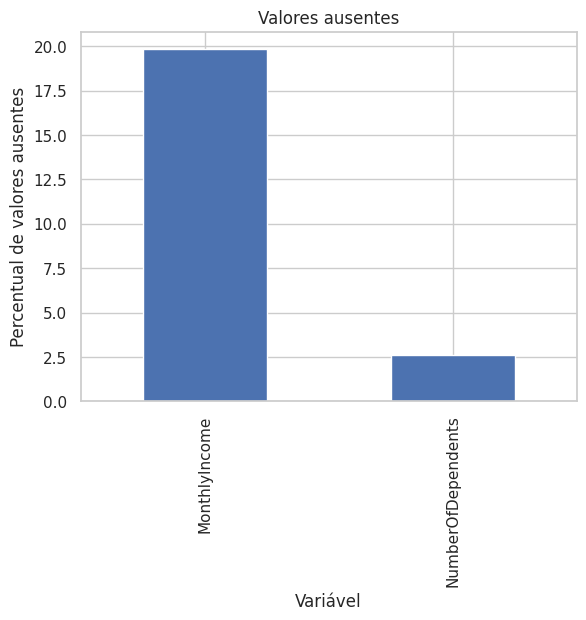

In [ ]:
faltantes[faltantes > 0].plot(
    kind="bar"
)

plt.ylabel(
    "Percentual de valores ausentes"
)

plt.xlabel(
    "Variável"
)

plt.title(
    "Valores ausentes"
)

plt.show()

**Tarefa 10**

**1. Quais variáveis possuem valores ausentes?**

Resposta: MonthlyIncome e NumberOfDependents.

**2. Qual possui a maior quantidade?**

Resposta: MonthlyIncome.

**3. Aproximadamente, qual porcentagem dos valores está ausente nessa variável?**

Resposta: Aproximadamente 19,82% dos valores de MonthlyIncome estão ausentes.


**4.3 Registros duplicados**

In [ ]:
credito.duplicated().sum()

np.int64(0)

**Tarefa 11**

**Existem registros duplicados? Se sim, quantos?**

Resposta: Não existem registros duplicados na base.

**4.4 Conhecendo a variável-alvo**

In [ ]:
credito[
    "SeriousDlqin2yrs"
].value_counts()

,count
SeriousDlqin2yrs,
0,139974
1,10026


In [ ]:
credito[
    "SeriousDlqin2yrs"
].value_counts(
    normalize=True
) * 100

,proportion
SeriousDlqin2yrs,
0,93.316
1,6.684


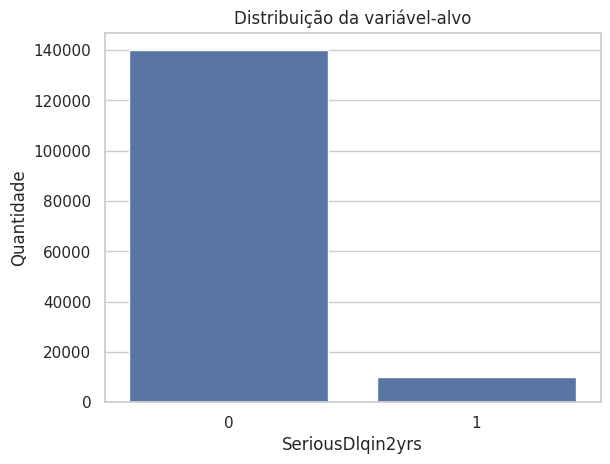

In [ ]:
sns.countplot(
    x="SeriousDlqin2yrs",
    data=credito
)

plt.xlabel(
    "SeriousDlqin2yrs"
)

plt.ylabel(
    "Quantidade"
)

plt.title(
    "Distribuição da variável-alvo"
)

plt.show()

**Tarefa 12**

**Qual é a porcentagem de registros da classe 0?**

Resposta: Aproximadamente 93,32% dos registros.

**Qual é a porcentagem da classe 1?**

Resposta: Aproximadamente 6,68% dos registros.

**Agora imagine um modelo que sempre respondesse 0. Qual seria sua acurácia?**

Resposta: A acurácia seria aproximadamente 93,32%, pois 93,32% dos registros pertencem à classe 0.

Observação: Isso mostra um forte desbalanceamento entre as classes e explica por que uma acurácia alta pode ser enganosa nesse problema.

**4.5 Observando as distribuições**

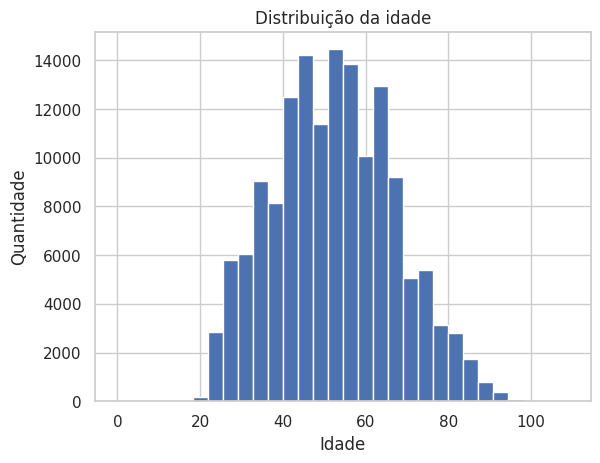

In [ ]:
credito["age"].hist(
    bins=30
)

plt.xlabel(
    "Idade"
)

plt.ylabel(
    "Quantidade"
)

plt.title(
    "Distribuição da idade"
)

plt.show()

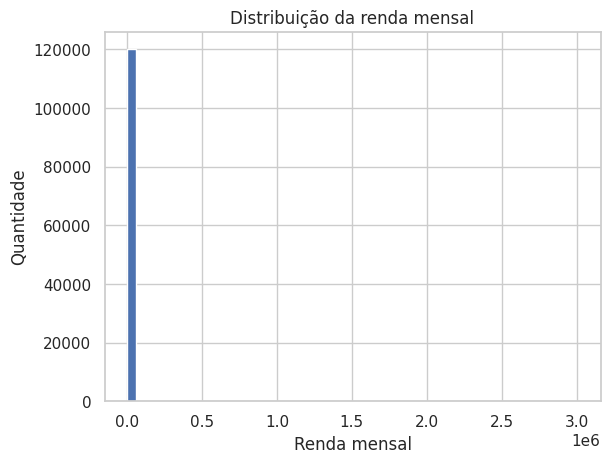

In [ ]:
credito["MonthlyIncome"].hist(
bins=50
)
plt.xlabel(
"Renda mensal"
)
plt.ylabel(
"Quantidade"
)
plt.title(
"Distribuição da renda mensal"
)
plt.show()


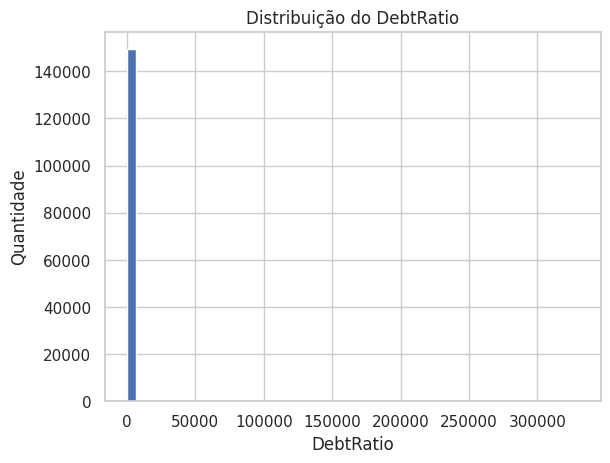

In [ ]:
credito[
    "DebtRatio"
].hist(
    bins=50
)

plt.xlabel(
    "DebtRatio"
)

plt.ylabel(
    "Quantidade"
)

plt.title(
    "Distribuição do DebtRatio"
)

plt.show()

**Tarefa 13**

**Observe os três gráficos. Para cada variável, escreva uma frase descrevendo o que você observa. Procure responder coisas como: os valores estão concentrados em alguma região? Existe uma cauda? Existem valores muito afastados da maior parte dos dados?**

Idade: A idade está concentrada principalmente na faixa de aproximadamente 40 a 65 anos. A distribuição apresenta valores mais afastados, incluindo idades muito baixas e muito altas.

Renda: A renda mensal está concentrada principalmente em valores relativamente baixos, mas apresenta uma longa cauda para a direita causada por pessoas com rendas muito elevadas. Portanto, a distribuição é bastante assimétrica.

DebtRatio: A distribuição do DebtRatio apresenta forte concentração em valores baixos e uma cauda longa para a direita, com alguns valores muito elevados e afastados da maior parte dos registros.

**4.6 Procurando valores extremos**

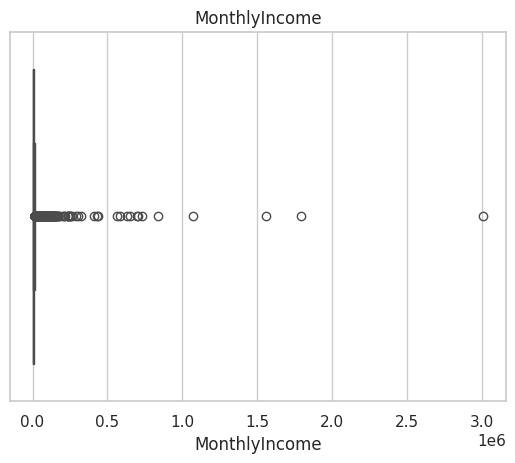

In [ ]:
sns.boxplot(
x=credito["MonthlyIncome"]
)
plt.title(
"MonthlyIncome"
)
plt.show()

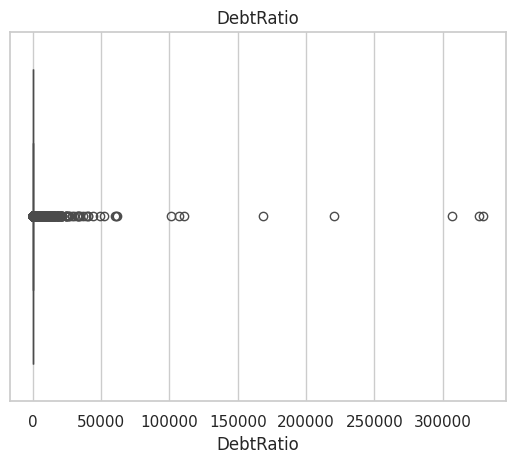

In [ ]:
sns.boxplot(
x=credito["DebtRatio"]
)
plt.title(
"DebtRatio"
)
plt.show()


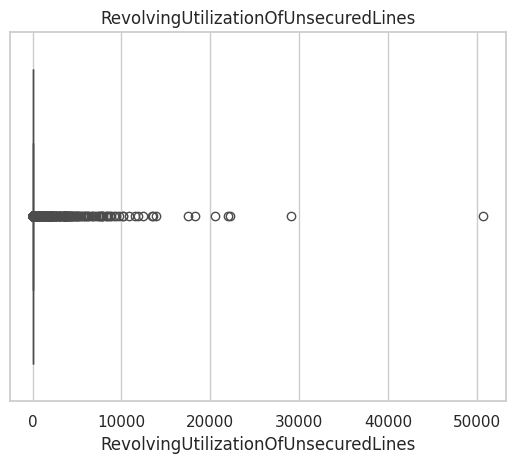

In [ ]:
sns.boxplot(
    x=credito[
        "RevolvingUtilizationOfUnsecuredLines"
    ]
)

plt.title(
    "RevolvingUtilizationOfUnsecuredLines"
)

plt.show()

**Tarefa 14**

**Escolha uma das três variáveis.
O boxplot apresenta possíveis valores extremos?
Descreva o que você observa.**

Variável escolhida: MonthlyIncome.

Resposta: Sim. O boxplot apresenta diversos possíveis valores extremos. A maior parte dos valores está concentrada em uma faixa relativamente baixa, enquanto alguns valores aparecem muito afastados, principalmente para a direita. Isso indica a presença de possíveis outliers.

**4.7 Assimetria**

In [ ]:
credito.skew(
    numeric_only=True
).sort_values(
    ascending=False
)

,0
MonthlyIncome,114.040318
RevolvingUtilizationOfUnsecuredLines,97.631574
DebtRatio,95.157793
NumberOfTime60-89DaysPastDueNotWorse,23.331743
NumberOfTimes90DaysLate,23.087345
NumberOfTime30-59DaysPastDueNotWorse,22.597108
NumberRealEstateLoansOrLines,3.482484
SeriousDlqin2yrs,3.468857
NumberOfDependents,1.588242
NumberOfOpenCreditLinesAndLoans,1.215314


**Tarefa 15**

**Qual variável apresenta a maior assimetria?
Volte ao histograma dessa variável.
O gráfico confirma a impressão produzida pelo valor de skew()?**

Resposta: A variável que apresenta a maior assimetria é NumberOfTime60-89DaysPastDueNotWorse. O histograma confirma essa impressão, pois os valores ficam fortemente concentrados próximos de zero e existe uma cauda para valores muito altos.

**4.8 Comparando as classes**

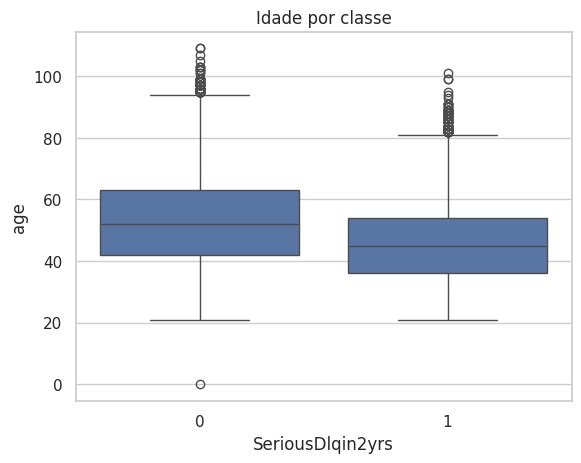

In [ ]:
sns.boxplot(
x="SeriousDlqin2yrs",
y="age",
data=credito
)
plt.title(
"Idade por classe"
)
plt.show()

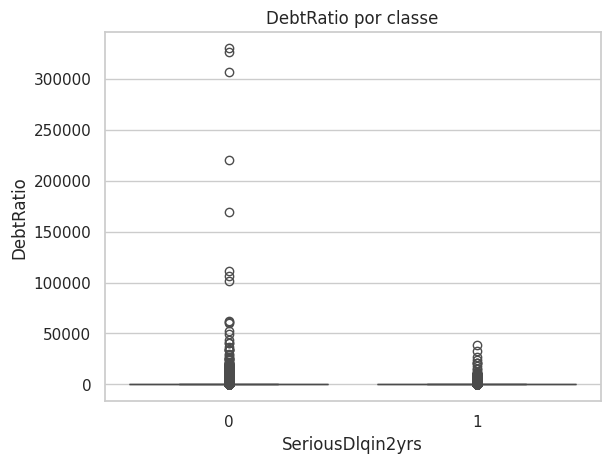

In [ ]:
sns.boxplot(
    x="SeriousDlqin2yrs",
    y="DebtRatio",
    data=credito
)

plt.title(
    "DebtRatio por classe"
)

plt.show()

In [ ]:
credito.groupby(
    "SeriousDlqin2yrs"
)[
    [
        "age",
        "DebtRatio",
        "NumberOfTimes90DaysLate",
        "NumberOfTime30-59DaysPastDueNotWorse"
    ]
].mean()

,age,DebtRatio,NumberOfTimes90DaysLate,NumberOfTime30-59DaysPastDueNotWorse
SeriousDlqin2yrs,,,,
0,52.751375,357.151168,0.135225,0.280109
1,45.926591,295.121066,2.091362,2.388490


**Tarefa 16**

**Escolha duas variáveis.
Compare seus valores entre as classes 0 e 1.
Existe alguma diferença aparente?**

Variáveis escolhidas: age e NumberOfTimes90DaysLate.

Resposta: A idade apresenta diferenças entre as classes 0 e 1. A classe 1 tende a apresentar idade média menor do que a classe 0.

NumberOfTimes90DaysLate apresenta uma diferença mais evidente entre as classes: pessoas da classe 1 tendem a apresentar mais ocorrências de atrasos de 90 dias ou mais.

Essas diferenças mostram uma associação entre as variáveis e a classe, mas não permitem afirmar que uma variável causa a outra.


**4.9 Correlação**

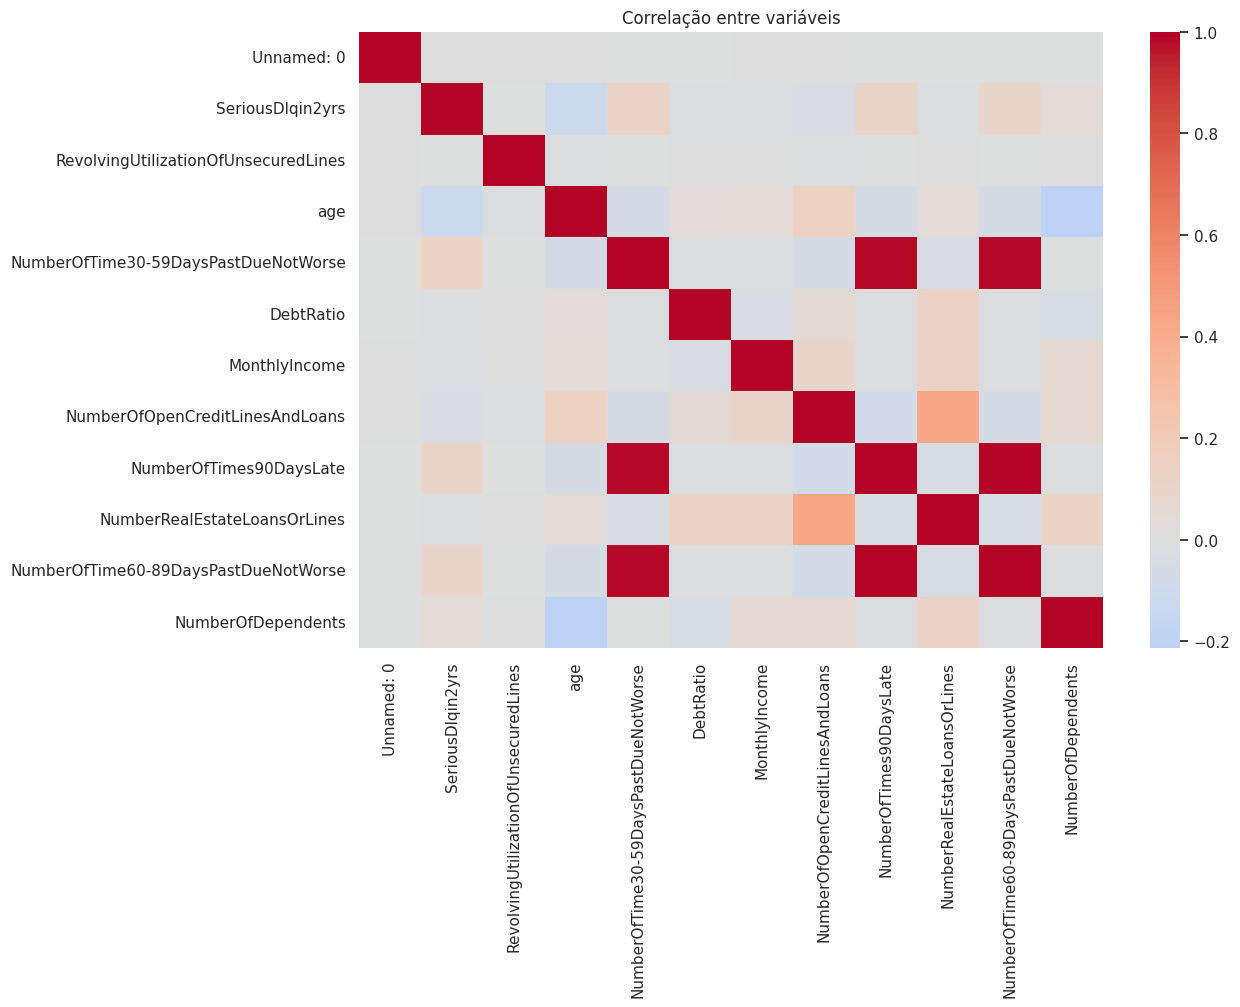

In [ ]:
correlacao = credito.corr(
numeric_only=True
)
plt.figure(
figsize=(12, 8)
)
sns.heatmap(
correlacao,
cmap="coolwarm",
center=0
)
plt.title(
"Correlação entre variáveis"
)
plt.show()

**Tarefa 17**

**Observe a matriz de correlação. Identifique:**

**1. um par de variáveis com correlação relativamente alta.**

Resposta: NumberOfTime30-59DaysPastDueNotWorse e NumberOfTimes90DaysLate.

**2. um par de variáveis com correlação próxima de zero.**

Resposta: age e NumberOfRealEstateLoansOrLines.



### Checkpoint 3

In [ ]:
diagnostico = pd.DataFrame({
    "Problema": [
        "Valores ausentes",
        "Desbalanceamento",
        "Possíveis outliers",
        "Assimetria",
        "Escalas diferentes",
        "Diferenças entre classes"
    ],

    "Existe?": [
        "Sim",
        "Sim",
        "Sim",
        "Sim",
        "Sim",
        "Sim"
    ],

    "Evidência": [
        "MonthlyIncome possui 29.731 valores ausentes e NumberOfDependents possui 3.924.",
        "A classe 0 representa aproximadamente 93,32% e a classe 1 aproximadamente 6,68%.",
        "Os boxplots mostram diversos valores muito afastados, principalmente em MonthlyIncome e DebtRatio.",
        "As variáveis apresentam valores elevados de skew, especialmente as variáveis relacionadas a atrasos.",
        "As variáveis possuem unidades e amplitudes muito diferentes, como age, MonthlyIncome e DebtRatio.",
        "Os boxplots e as médias por classe mostram diferenças entre as classes em algumas variáveis."
    ]
})

diagnostico

,Problema,Existe?,Evidência
0,Valores ausentes,Sim,MonthlyIncome possui 29.731 valores ausentes e...
1,Desbalanceamento,Sim,"A classe 0 representa aproximadamente 93,32% e..."
2,Possíveis outliers,Sim,Os boxplots mostram diversos valores muito afa...
3,Assimetria,Sim,As variáveis apresentam valores elevados de sk...
4,Escalas diferentes,Sim,As variáveis possuem unidades e amplitudes mui...
5,Diferenças entre classes,Sim,Os boxplots e as médias por classe mostram dif...


**Mostre a tabela de diagnóstico preenchida. Para cada problema identificado, apresente a evidência numérica ou gráfica correspondente.**

Print da tabela:

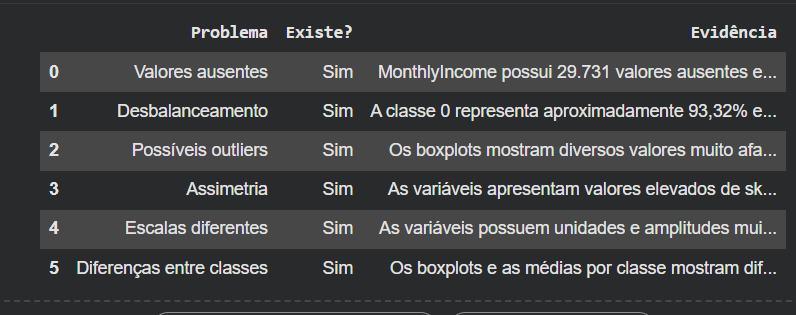

**Evidências apresentadas**

- Valores ausentes: resultado de `credito.isna().sum()`.
- Desbalanceamento: distribuição de `SeriousDlqin2yrs`.
- Outliers: boxplots de `MonthlyIncome`, `DebtRatio` e `RevolvingUtilizationOfUnsecuredLines`.
- Assimetria: resultado de `credito.skew()`.
- Escalas diferentes: comparação das amplitudes das variáveis.
- Diferenças entre classes: boxplots e médias agrupadas por `SeriousDlqin2yrs`.

**Valores ausentes**

Print:

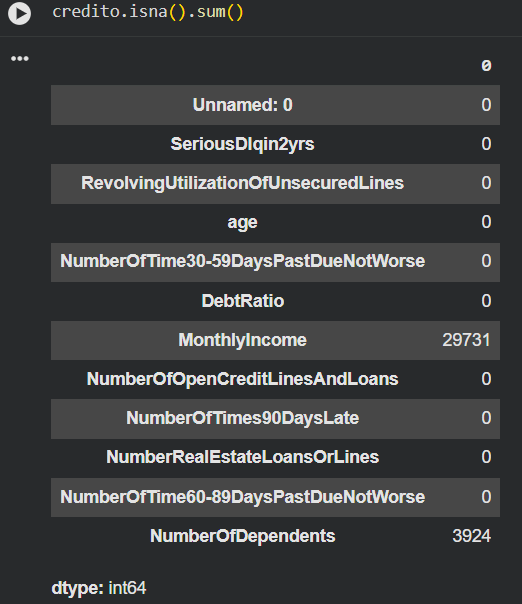

**Desbalanceamento**

Print:

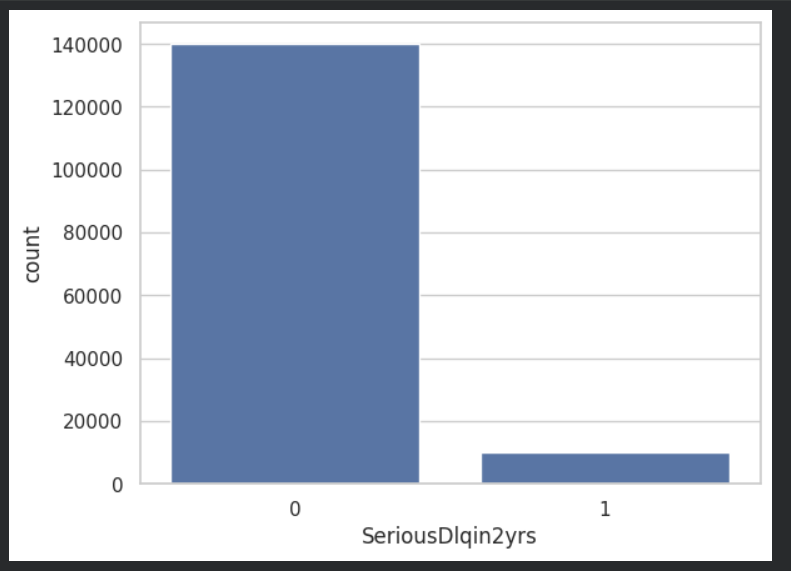

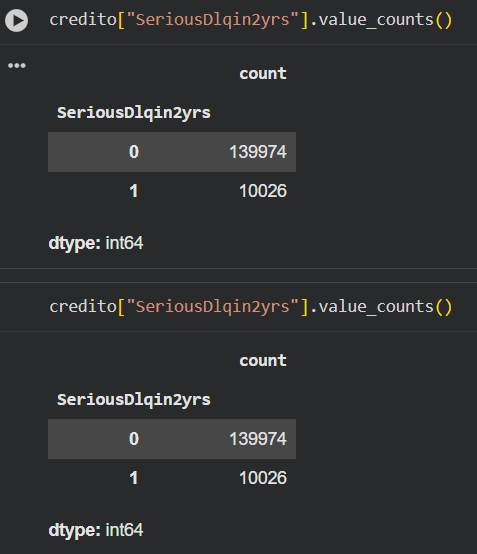

**Possíveis outliers**

Print:

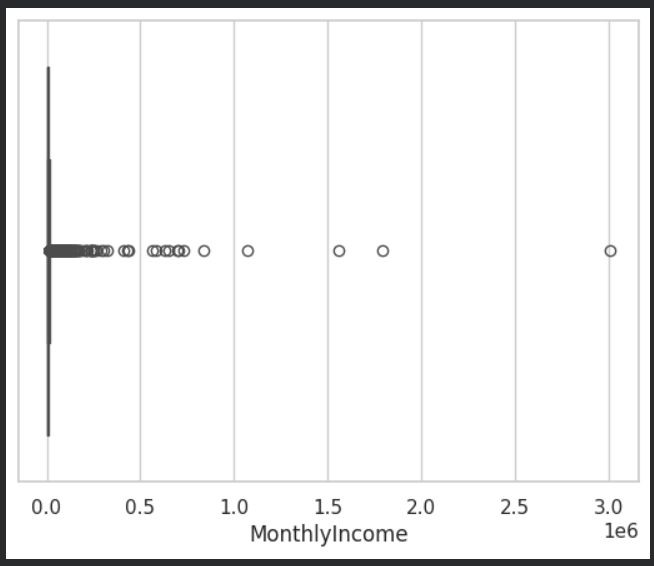

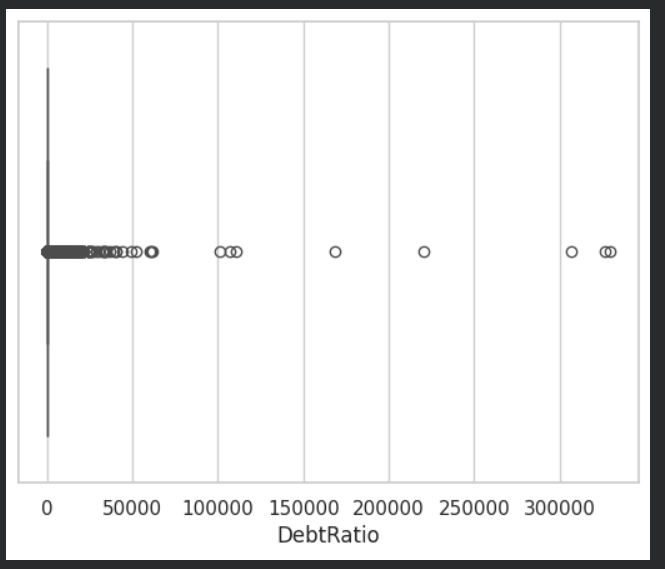

**Assimetria**

Print:

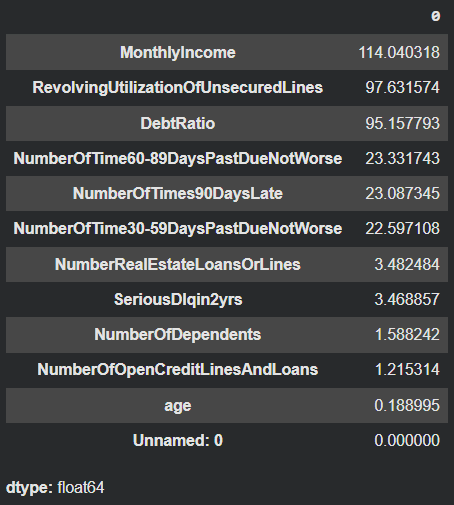

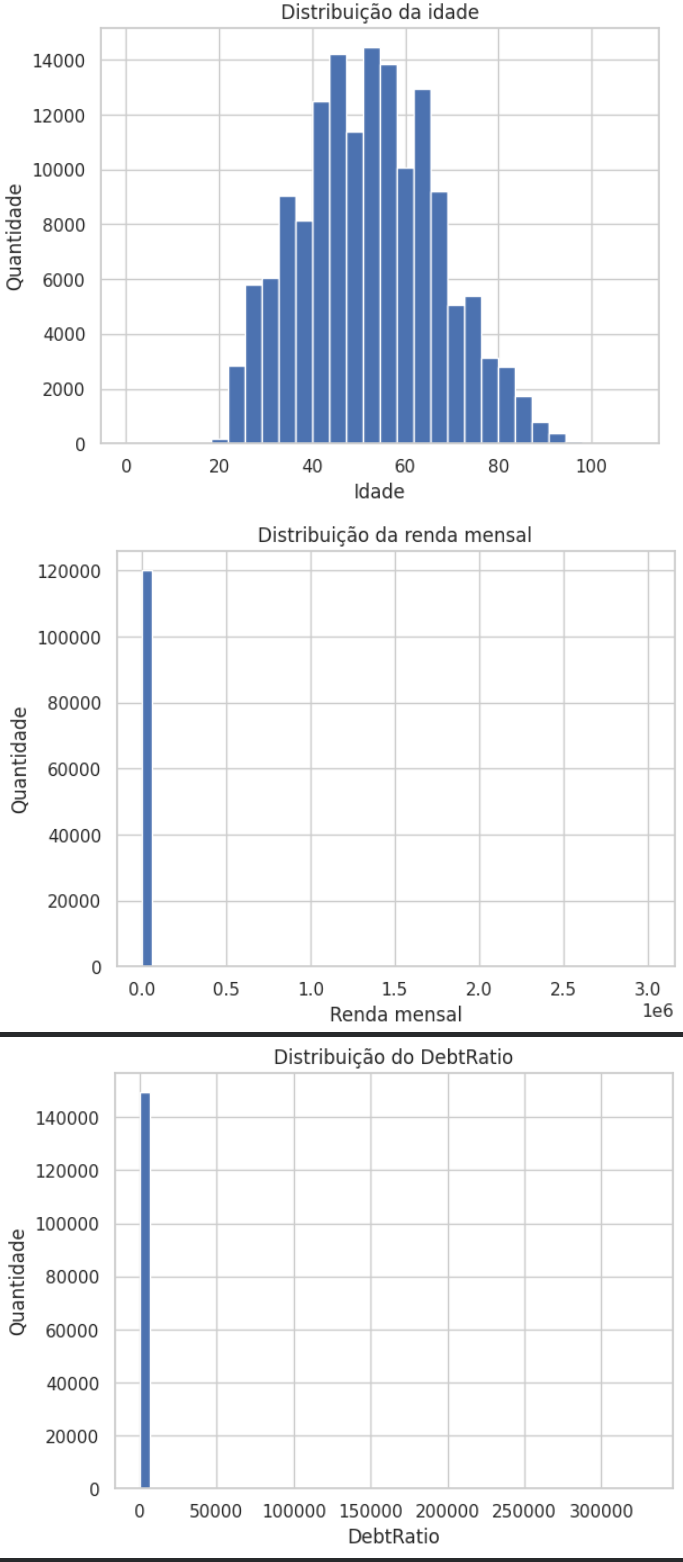

**Escalas diferentes**

Print:

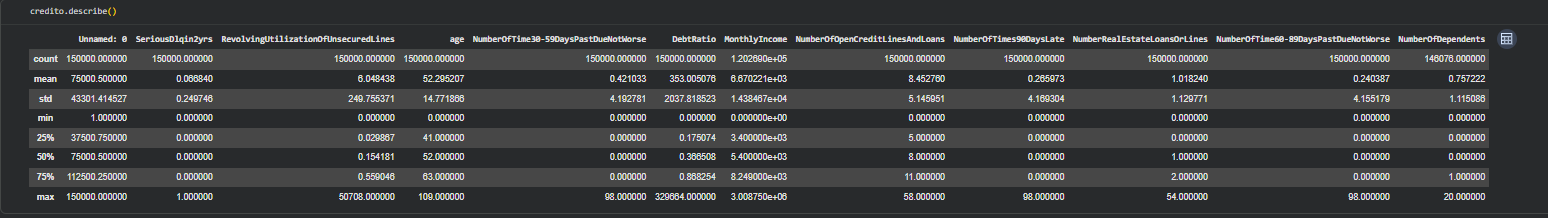

**Diferenças entre classes**

Print:

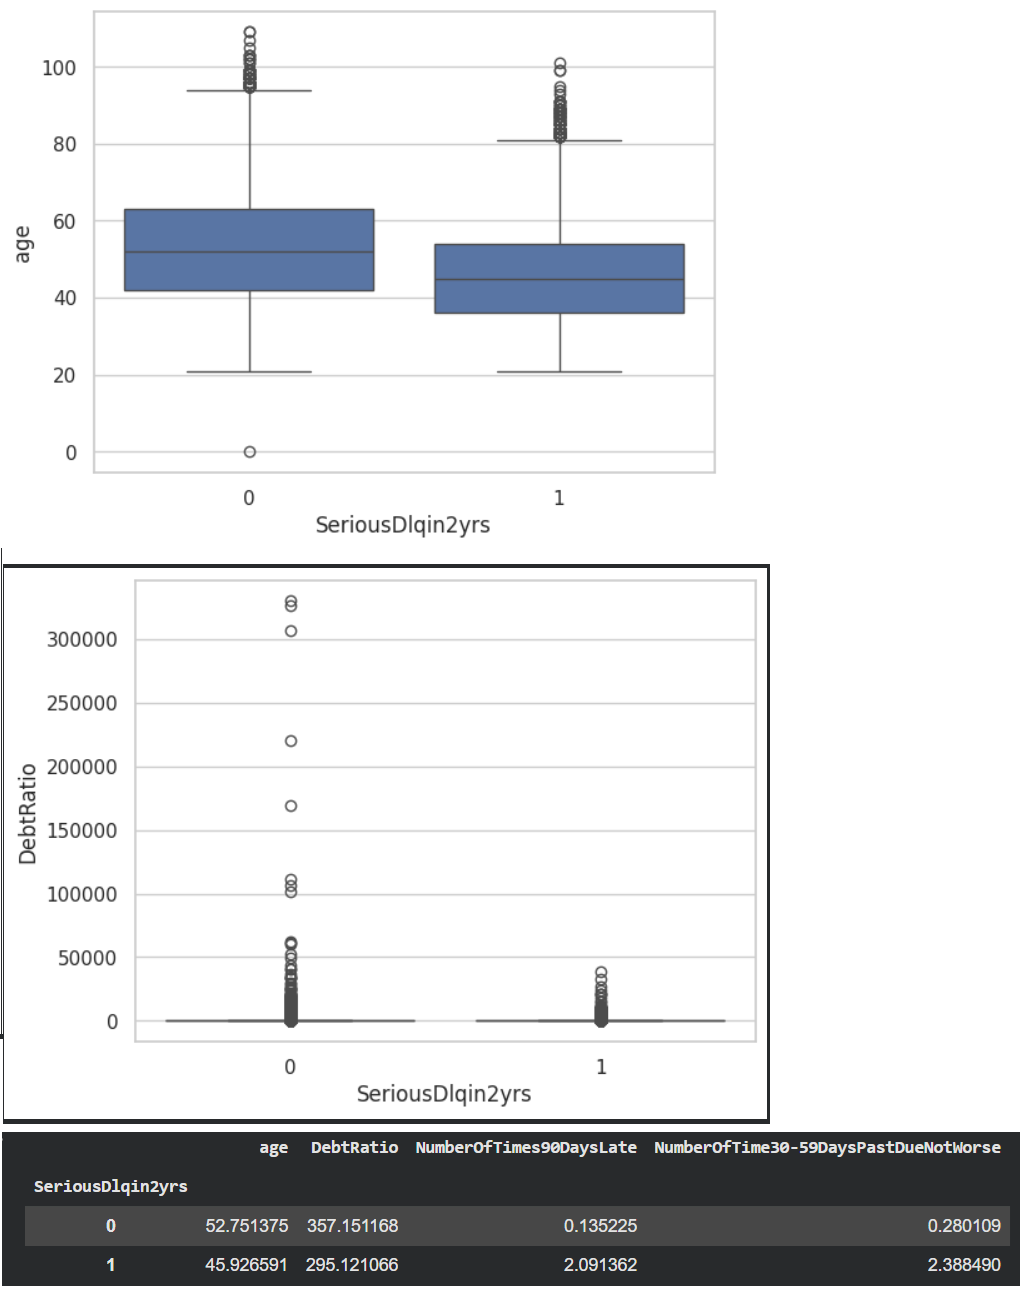

# Pergunta final

Antes desta prática, nós achávamos que avaliar um modelo significava observar principalmente a acurácia obtida no conjunto de teste.

Depois desta prática, entendemos que avaliar um modelo envolve analisar diferentes divisões dos dados, validação cruzada, matriz de confusão, precision, recall e F1, pois cada métrica pode mostrar aspectos diferentes do desempenho.

Na base Give Me Some Credit, o problema que mais nos chamou atenção foi o desbalanceamento das classes, porque aproximadamente 93,32% dos registros pertencem à classe 0, enquanto apenas 6,68% pertencem à classe 1. Isso mostra que uma acurácia aparentemente alta pode não significar que o modelo esteja identificando bem a classe minoritária.